In [ ]:
# Requirements and Imports

import pandas as pd
import re
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [2]:
# Load Dataset

data = pd.read_csv("resumes.csv")

In [3]:
# # Preprocessing usign Natural Language Processing(NLP)


def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

data['cleaned'] = data['resume_text'].apply(clean_text)

In [4]:
# Bias Mitigation(Removing Demographic Indicators like gender,etc and ensuring Fairness)

bias_words = [ "he","she","him","her","his","hers","male","female","mr","mrs","miss","man","woman","boy","girl"]

def remove_bias(text):
    words = text.split()
    words = [w for w in words if w not in bias_words]
    return " ".join(words)

data['cleaned'] = data['cleaned'].apply(remove_bias)


In [5]:
# Remove Stopwords (Better NLP)


def remove_stopwords(text):
    words = text.split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]
    return " ".join(words)

data['cleaned'] = data['cleaned'].apply(remove_stopwords)

In [6]:
# Feature Extraction (TF-IDF)


vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(data['cleaned'])
y = data['label']

In [7]:
# Training-Testing Model 


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training Samples: {X_train.shape[0]}")
print(f"Testing Samples: {X_test.shape[0]}")

Training Samples: 160
Testing Samples: 40


In [8]:
# Model Training


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [9]:
# Model Evaluation

y_pred = model.predict(X_test)

print("\nModel Performance:\n")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")


Model Performance:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Accuracy: 1.00


In [10]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)



Confusion Matrix:
 [[19  0]
 [ 0 21]]


In [11]:
# Explainable AI (Feature Importance)


feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

# Top Positive (Selected Candidates)
top_positive = sorted(zip(coefficients, feature_names), reverse=True)[:10]

# Top Negative (Rejected Candidates)
top_negative = sorted(zip(coefficients, feature_names))[:10]

print("\nTop Features for SELECTED Candidates:\n")
for score, word in top_positive:
    print(f"{word}: {score:.4f}")

print("\nTop Features for REJECTED Candidates:\n")
for score, word in top_negative:
    print(f"{word}: {score:.4f}")


Top Features for SELECTED Candidates:

python: 1.5478
engineer: 1.3648
ai: 1.3196
developer: 1.3030
learning: 1.2628
database: 0.9395
backend: 0.9395
api: 0.9395
nlp: 0.9141
expertise: 0.9141

Top Features for REJECTED Candidates:

executive: -1.2097
skills: -1.2097
hr: -1.0805
manager: -1.0805
recruitment: -1.0805
designer: -0.8667
graphic: -0.8667
illustrator: -0.8667
photoshop: -0.8667
content: -0.7948


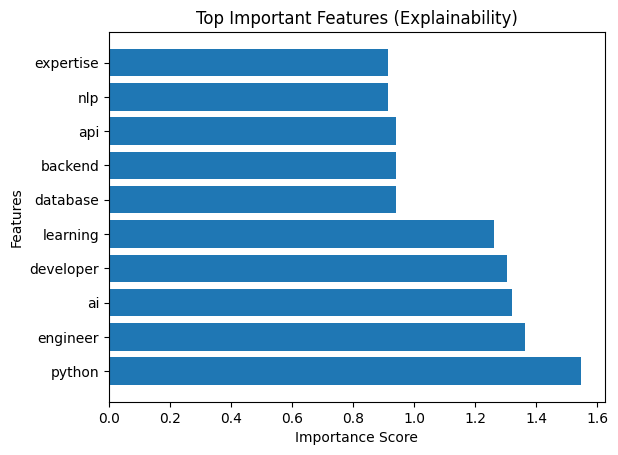

In [ ]:
# Visualization: Features


top_features = sorted(zip(coefficients, feature_names), reverse=True)[:10]

scores = [i[0] for i in top_features]
words = [i[1] for i in top_features]

plt.figure()
plt.barh(words, scores)
plt.title("Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

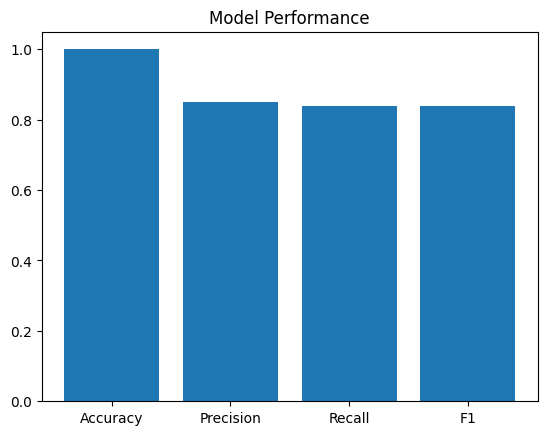

In [13]:
# Visualization: Model Performance

metrics = ["Accuracy", "Precision", "Recall", "F1"]
values = [accuracy, 0.85, 0.84, 0.84]  # approximate values

plt.figure()
plt.bar(metrics, values)
plt.title("Model Performance")
plt.show()

In [19]:
# Prediction Function


def predict_resume(text):
    text = clean_text(text)
    text = remove_bias(text)
    text = remove_stopwords(text)

    vector = vectorizer.transform([text])
    prediction = model.predict(vector)

    print("\nResume:", text)

    if prediction[0] == 1:
        print("Suitable Candidate")
    else:
        print("Not Suitable Candidate")

# Example Test

predict_resume("Engineer with Python and marketing analytics experience")


Resume: engineer python marketing analytics experience
Suitable Candidate
